# TabM

Проверяю табличную DL-модель с параметрически-эффективным ансамблированием на тех же наборах признаков и той же валидационной части.

In [1]:
from pathlib import Path

import gc
import os
import random
import pickle
import warnings

for warn in [UserWarning, FutureWarning]:
    warnings.filterwarnings("ignore", category=warn)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna

from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score  # классы несбалансированы
from sklearn.metrics import average_precision_score  # положительный класс -- редкий
from sklearn.metrics import balanced_accuracy_score  # accuracy для дисбаланса
from sklearn.metrics import f1_score
from sklearn.metrics import precision_recall_curve
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

PROJECT_DIR = Path("/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton")
DATA_DIR = PROJECT_DIR / "data"
BASE_DIR = DATA_DIR

LOGS_DIR = PROJECT_DIR / "logs" / "tabm_optuna_log"
MODELS_DIR = PROJECT_DIR / "models" / "tabm_models"
SUBMISSIONS_DIR = PROJECT_DIR / "submissions"

LOGS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("BASE_DIR:", BASE_DIR)
print("LOGS_DIR:", LOGS_DIR)
print("MODELS_DIR:", MODELS_DIR)
print("SUBMISSIONS_DIR:", SUBMISSIONS_DIR)

optuna.logging.set_verbosity(optuna.logging.WARNING)

Device: mps
PROJECT_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton
BASE_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data
LOGS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/logs/tabm_optuna_log
MODELS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models
SUBMISSIONS_DIR: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions


## Загрузка данных

In [3]:
feature_sets = [
    "top300",
    "top500_clean",
    "top500_lgb_clean",
    "top500_magic_meta",
    "top500_micro_engineered",
]


def resolve_feature_path(folder, split):
    file_name = f"X_{split}_{folder}.parquet"
    candidates = [
        BASE_DIR / folder / file_name,
        BASE_DIR / file_name,
        BASE_DIR / "processed_data" / folder / file_name,
        BASE_DIR / "processed_data" / file_name,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не нашел файл с признаками. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


def resolve_target_path(name):
    candidates = [
        BASE_DIR / f"y_{name}.parquet",
        BASE_DIR / "processed_data" / f"y_{name}.parquet",
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(
        "Не нашел target-файл. Проверенные пути:\n"
        + "\n".join(str(path) for path in candidates)
    )


def read_feature_matrix(folder, split):
    path = resolve_feature_path(folder, split)
    print(f"read {split:<13} {folder:<25} -> {path}")
    return pd.read_parquet(path)


def read_target(name):
    path = resolve_target_path(name)
    print(f"read target {name:<13} -> {path}")
    return pd.read_parquet(path).iloc[:, 0].values.ravel()


def check_feature_sets():
    rows = []
    for folder in feature_sets:
        row = {"feature_set": folder}
        for split in ["train_sampled", "train_full", "val", "test"]:
            try:
                row[split] = resolve_feature_path(folder, split).exists()
            except FileNotFoundError:
                row[split] = False
        rows.append(row)

    return pd.DataFrame(rows)

check_feature_sets()

,feature_set,train_sampled,train_full,val,test
0,top300,True,True,True,True
1,top500_clean,True,True,True,True
2,top500_lgb_clean,True,True,True,True
3,top500_magic_meta,True,True,True,True
4,top500_micro_engineered,True,True,True,True


## Метрики и подбор порога

In [4]:
def count_metrics(y_true, y_pred, y_score):
    """
    roc_auc_score: вероятность того, что модель присвоит случайному объекту класса 1 более высокий score, чем случайному объекту класса 0; чем ближе к 1, тем лучше разделение классов, 0.5 — уровень случайного угадывания.

    average_precision_score: среднее качество поиска объектов класса 1 по всем возможным порогам; высокая метрика означает, что среди объектов, которые модель считает наиболее похожими на класс 1, действительно много единиц.

    balanced_accuracy_score: средняя точность отдельно по классу 0 и по классу 1; полезна при дисбалансе классов, потому что не дает модели выглядеть хорошей только за счет угадывания самого частого класса.

    f1_score: одна итоговая оценка качества предсказания класса 1, которая будет высокой только тогда, когда модель одновременно находит много настоящих единиц и не слишком часто ошибочно объявляет нули единицами.
    """

    print("roc auc:", roc_auc_score(y_true, y_score))
    print("average precision:", average_precision_score(y_true, y_score))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("f1:", f1_score(y_true, y_pred, zero_division=0))


def best_f1_threshold(y_true, y_score):
    """Подбираем порог по train-score, чтобы .predict() с 0.5 не превращал всё в нули.

    ROC AUC при этом не меняется: он считается по y_score, а не по бинарному y_pred.
    """

    precision, recall, thresholds = precision_recall_curve(y_true, y_score)

    precision = precision[:-1]
    recall = recall[:-1]

    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    if len(thresholds) == 0:
        return 0.5

    return thresholds[np.argmax(f1)]


def predict_with_threshold(y_score, threshold):
    return (y_score >= threshold).astype(int)

## Подготовка матриц

In [5]:
def prepare_matrices(X_train, X_val):
    scaler = StandardScaler()

    X_train_np = X_train.to_numpy(dtype=np.float32, copy=True)
    X_val_np = X_val.to_numpy(dtype=np.float32, copy=True)

    X_train_np = np.nan_to_num(X_train_np, nan=0.0, posinf=0.0, neginf=0.0)
    X_val_np = np.nan_to_num(X_val_np, nan=0.0, posinf=0.0, neginf=0.0)

    X_train_np = scaler.fit_transform(X_train_np).astype(np.float32)
    X_val_np = scaler.transform(X_val_np).astype(np.float32)

    return X_train_np, X_val_np, scaler


def count_parameters(model):
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

## Архитектура модели

In [6]:
MODEL_NAME = "TabM"
MODEL_PREFIX = "tabm"


def make_loader(X, y, batch_size, shuffle, params):
    x_tensor = torch.from_numpy(X.astype(np.float32))
    y_tensor = torch.from_numpy(y.astype(np.float32)).view(-1, 1)
    dataset = TensorDataset(x_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        drop_last=shuffle,
    )


def make_loader_for_prediction(X, batch_size, params):
    x_tensor = torch.from_numpy(X.astype(np.float32))
    y_tensor = torch.zeros((len(X), 1), dtype=torch.float32)
    dataset = TensorDataset(x_tensor, y_tensor)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )


class BatchEnsembleLinear(nn.Module):
    def __init__(self, in_features, out_features, ensemble_size, bias=True):
        super(BatchEnsembleLinear, self).__init__()

        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self.r = nn.Parameter(torch.randn(ensemble_size, in_features) * 0.02 + 1.0)
        self.s = nn.Parameter(torch.randn(ensemble_size, out_features) * 0.02 + 1.0)

    def forward(self, x):
        # x: batch, ensemble, features
        x = x * self.r.unsqueeze(0)
        x = self.linear(x)
        x = x * self.s.unsqueeze(0)
        return x


class TabMBlock(nn.Module):
    def __init__(self, in_features, out_features, ensemble_size, dropout):
        super(TabMBlock, self).__init__()

        self.linear = BatchEnsembleLinear(in_features, out_features, ensemble_size)
        self.norm = nn.LayerNorm(out_features)
        self.activation = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.linear(x)
        x = self.norm(x)
        x = self.activation(x)
        x = self.dropout(x)
        return x


class TabM(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, n_layers=2, ensemble_size=8, dropout=0.2):
        super(TabM, self).__init__()

        self.ensemble_size = ensemble_size
        layers = []
        current_dim = input_dim

        for _ in range(n_layers):
            layers.append(TabMBlock(current_dim, hidden_dim, ensemble_size, dropout))
            current_dim = hidden_dim

        self.backbone = nn.Sequential(*layers)
        self.head = BatchEnsembleLinear(current_dim, 1, ensemble_size)

    def forward(self, x):
        x = x.unsqueeze(1).expand(-1, self.ensemble_size, -1)
        x = self.backbone(x)
        logits = self.head(x).squeeze(-1)
        return logits.mean(dim=1, keepdim=True)


def make_model(input_dim, params):
    return TabM(
        input_dim=input_dim,
        hidden_dim=params["hidden_dim"],
        n_layers=params["n_layers"],
        ensemble_size=params["ensemble_size"],
        dropout=params["dropout"],
    ).to(DEVICE)

## Обучение модели

In [7]:
def run_epoch(model, loader, criterion, optimizer=None):
    train = optimizer is not None
    model.train(train)

    total_loss = 0.0
    all_scores = []
    all_targets = []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            if train:
                optimizer.zero_grad(set_to_none=True)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)

            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(x_batch)

            scores = torch.sigmoid(logits).detach().cpu().numpy().ravel()
            targets = y_batch.detach().cpu().numpy().ravel()
            all_scores.append(scores)
            all_targets.append(targets)

    all_scores = np.concatenate(all_scores)
    all_targets = np.concatenate(all_targets)
    auc = roc_auc_score(all_targets, all_scores)
    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, auc


def train_model(model, train_loader, val_loader, criterion, optimizer, max_epochs=10, patience=2):
    best_auc = -np.inf
    best_state = None
    history = []
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_auc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_auc = run_epoch(model, val_loader, criterion)

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_auc": train_auc,
                "val_loss": val_loss,
                "val_auc": val_auc,
            }
        )

        print(
            f"epoch {epoch:02d}/{max_epochs} | "
            f"train loss {train_loss:.5f} auc {train_auc:.5f} | "
            f"val loss {val_loss:.5f} auc {val_auc:.5f}"
        )

        if val_auc > best_auc:
            best_auc = val_auc
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return best_auc, history, best_state


def load_checkpoint(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


@torch.no_grad()
def predict_scores(model, loader):
    model.eval()
    all_scores = []

    for x_batch, _ in loader:
        x_batch = x_batch.to(DEVICE)
        logits = model(x_batch)
        scores = torch.sigmoid(logits).detach().cpu().numpy().ravel()
        all_scores.append(scores)

    return np.concatenate(all_scores)

## Функция для оптимизации параметров с помощью optuna

In [8]:
def objective(trial, X_train, y_train, X_val, y_val, max_epochs, patience):
    params = {
        "hidden_dim": trial.suggest_categorical("hidden_dim", [128, 256, 384]),
        "n_layers": trial.suggest_int("n_layers", 1, 3),
        "ensemble_size": trial.suggest_categorical("ensemble_size", [4, 8, 12]),
        "dropout": trial.suggest_float("dropout", 0.05, 0.35),
        "lr": trial.suggest_float("lr", 1e-4, 2e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 2048, 4096]),
        "pos_weight_mult": trial.suggest_float("pos_weight_mult", 0.5, 1.5),
    }

    train_loader = make_loader(X_train, y_train, params["batch_size"], shuffle=True, params=params)
    val_loader = make_loader(X_val, y_val, params["batch_size"], shuffle=False, params=params)

    model = make_model(X_train.shape[1], params)

    pos_count = np.maximum(y_train.sum(), 1)
    neg_count = len(y_train) - y_train.sum()
    pos_weight = (neg_count / pos_count) * params["pos_weight_mult"]
    pos_weight = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    best_auc, history, _ = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        max_epochs=max_epochs,
        patience=patience,
    )

    trial.set_user_attr("n_params", count_parameters(model))
    trial.set_user_attr("last_epoch", history[-1]["epoch"])

    del model, train_loader, val_loader, criterion, optimizer
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return best_auc

In [9]:
def logging_callback(study, trial):
    set_name = study.user_attrs.get("set_name", "unknown")
    train_mode = study.user_attrs.get("train_mode", "unknown")
    log_file_path = LOGS_DIR / f"{set_name}_{train_mode}_optimization.log"

    with open(log_file_path, "a") as f:
        f.write(
            f"Trial {trial.number:03d} finished | "
            f"ROC-AUC: {trial.value:.5f} | "
            f"Best ROC-AUC so far: {study.best_value:.5f}\n"
        )

## Подбор параметров на усеченной обучающей выборке

In [10]:
OPTUNA_N_TRIALS_SAMPLED = 20
OPTUNA_TIMEOUT_SAMPLED = 1800
SAMPLED_MAX_EPOCHS = 6
SAMPLED_PATIENCE = 2

y_train_sampled = read_target("train_sampled")
y_val = read_target("val")

best_params_sampled = {}
best_scores_sampled = {}

read target train_sampled -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_train_sampled.parquet
read target val           -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_val.parquet


In [11]:
for folder in feature_sets:
    print(f"\n==================================================")
    print(f" НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: {folder}")
    print(f"==================================================")

    X_train_sampled = read_feature_matrix(folder, "train_sampled")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_sampled) == len(y_train_sampled)
    assert len(X_val) == len(y_val)

    X_train_sampled_np, X_val_np, _ = prepare_matrices(X_train_sampled, X_val)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.set_user_attr("set_name", folder)
    study.set_user_attr("train_mode", "sampled")

    log_file_path = LOGS_DIR / f"{folder}_sampled_optimization.log"
    if log_file_path.exists():
        log_file_path.unlink()

    study.optimize(
        lambda trial: objective(
            trial,
            X_train_sampled_np,
            y_train_sampled,
            X_val_np,
            y_val,
            max_epochs=SAMPLED_MAX_EPOCHS,
            patience=SAMPLED_PATIENCE,
        ),
        n_trials=OPTUNA_N_TRIALS_SAMPLED,
        timeout=OPTUNA_TIMEOUT_SAMPLED,
        callbacks=[logging_callback],
        show_progress_bar=True,
    )

    best_params_sampled[folder] = study.best_params
    best_scores_sampled[folder] = study.best_value

    print(f"\n УСПЕШНО ЗАВЕРШЕНО ДЛЯ: {folder}")
    print(f" Лучший ROC-AUC на валидации: {study.best_value:.5f}")
    print(f" Подробный лог сохранен в: {log_file_path}")
    print(" Лучшие параметры:")
    for param, value in study.best_params.items():
        print(f"   -> {param}: {value}")

    del X_train_sampled, X_val, X_train_sampled_np, X_val_np, study
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОПТИМИЗАЦИЯ НА УСЕЧЕННЫХ ВЫБОРКАХ ЗАВЕРШЕНА!")
print("==================================================")


 НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: top300
read train_sampled top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_sampled_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet


  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.05587 auc 0.59394 | val loss 0.65160 auc 0.62035
epoch 02/6 | train loss 1.00685 auc 0.66333 | val loss 0.62810 auc 0.63517
epoch 03/6 | train loss 0.98194 auc 0.69026 | val loss 0.61872 auc 0.62767
epoch 04/6 | train loss 0.94824 auc 0.71756 | val loss 0.63833 auc 0.63376
epoch 01/6 | train loss 0.93177 auc 0.60139 | val loss 0.58722 auc 0.62817
epoch 02/6 | train loss 0.88388 auc 0.67266 | val loss 0.51400 auc 0.62547
epoch 03/6 | train loss 0.84957 auc 0.71363 | val loss 0.55633 auc 0.63906
epoch 04/6 | train loss 0.80311 auc 0.75744 | val loss 0.51465 auc 0.63786
epoch 05/6 | train loss 0.75376 auc 0.79684 | val loss 0.48904 auc 0.62489
epoch 01/6 | train loss 1.12676 auc 0.56854 | val loss 0.64841 auc 0.60049
epoch 02/6 | train loss 1.08552 auc 0.64140 | val loss 0.65640 auc 0.61706
epoch 03/6 | train loss 1.05427 auc 0.67786 | val loss 0.67167 auc 0.62907
epoch 04/6 | train loss 1.02436 auc 0.70737 | val loss 0.66117 auc 0.62832
epoch 05/6 | train loss 0

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.05363 auc 0.59895 | val loss 0.68238 auc 0.61921
epoch 02/6 | train loss 0.99547 auc 0.67469 | val loss 0.62792 auc 0.62585
epoch 03/6 | train loss 0.95201 auc 0.71630 | val loss 0.64992 auc 0.62241
epoch 04/6 | train loss 0.89989 auc 0.75846 | val loss 0.62250 auc 0.63933
epoch 05/6 | train loss 0.83903 auc 0.79962 | val loss 0.62870 auc 0.63390
epoch 06/6 | train loss 0.78082 auc 0.83151 | val loss 0.69146 auc 0.62125
epoch 01/6 | train loss 0.92864 auc 0.60523 | val loss 0.59844 auc 0.62761
epoch 02/6 | train loss 0.86851 auc 0.69053 | val loss 0.49999 auc 0.63902
epoch 03/6 | train loss 0.81061 auc 0.75023 | val loss 0.52031 auc 0.63615
epoch 04/6 | train loss 0.74054 auc 0.80464 | val loss 0.51773 auc 0.64550
epoch 05/6 | train loss 0.65992 auc 0.85592 | val loss 0.49129 auc 0.63568
epoch 06/6 | train loss 0.58022 auc 0.89501 | val loss 0.57071 auc 0.62673
epoch 01/6 | train loss 1.11933 auc 0.58452 | val loss 0.75451 auc 0.58939
epoch 02/6 | train loss 1

...

epoch 01/6 | train loss 1.05364 auc 0.59417 | val loss 0.59557 auc 0.61703
epoch 02/6 | train loss 0.99177 auc 0.67868 | val loss 0.58991 auc 0.63192
epoch 03/6 | train loss 0.94453 auc 0.72254 | val loss 0.60422 auc 0.63179
epoch 04/6 | train loss 0.88443 auc 0.76971 | val loss 0.65977 auc 0.61836
epoch 01/6 | train loss 0.93151 auc 0.59595 | val loss 0.50290 auc 0.62303
epoch 02/6 | train loss 0.87068 auc 0.69152 | val loss 0.57128 auc 0.62854
epoch 03/6 | train loss 0.80742 auc 0.75362 | val loss 0.50294 auc 0.63318
epoch 04/6 | train loss 0.72981 auc 0.81457 | val loss 0.49915 auc 0.62468
epoch 05/6 | train loss 0.65457 auc 0.85956 | val loss 0.47004 auc 0.62094
epoch 01/6 | train loss 1.11609 auc 0.58831 | val loss 0.66224 auc 0.59910
epoch 02/6 | train loss 1.06431 auc 0.66717 | val loss 0.66703 auc 0.61636
epoch 03/6 | train loss 1.01827 auc 0.70959 | val loss 0.70917 auc 0.62610
epoch 04/6 | train loss 0.96422 auc 0.75528 | val loss 0.64438 auc 0.62834
epoch 05/6 | train loss 0

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.04826 auc 0.60310 | val loss 0.66537 auc 0.62909
epoch 02/6 | train loss 0.99527 auc 0.67575 | val loss 0.63725 auc 0.62573
epoch 03/6 | train loss 0.95455 auc 0.71571 | val loss 0.57378 auc 0.64277
epoch 04/6 | train loss 0.90352 auc 0.75543 | val loss 0.55576 auc 0.63844
epoch 05/6 | train loss 0.85219 auc 0.79162 | val loss 0.62317 auc 0.63679
epoch 01/6 | train loss 0.92438 auc 0.60846 | val loss 0.52983 auc 0.61916
epoch 02/6 | train loss 0.86832 auc 0.69247 | val loss 0.55688 auc 0.64142
epoch 03/6 | train loss 0.81337 auc 0.74632 | val loss 0.54078 auc 0.63855
epoch 04/6 | train loss 0.73918 auc 0.80675 | val loss 0.62021 auc 0.63869
epoch 01/6 | train loss 1.12019 auc 0.57803 | val loss 0.66261 auc 0.60377
epoch 02/6 | train loss 1.06562 auc 0.66584 | val loss 0.70171 auc 0.62526
epoch 03/6 | train loss 1.02496 auc 0.70228 | val loss 0.68331 auc 0.63486
epoch 04/6 | train loss 0.97344 auc 0.74723 | val loss 0.68715 auc 0.63328
epoch 05/6 | train loss 0

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/6 | train loss 1.04666 auc 0.60713 | val loss 0.66569 auc 0.61156
epoch 02/6 | train loss 0.98208 auc 0.68500 | val loss 0.66945 auc 0.62127
epoch 03/6 | train loss 0.92055 auc 0.74239 | val loss 0.60528 auc 0.62576
epoch 04/6 | train loss 0.84120 auc 0.79597 | val loss 0.64734 auc 0.61887
epoch 05/6 | train loss 0.75568 auc 0.84270 | val loss 0.66395 auc 0.61011
epoch 01/6 | train loss 0.92401 auc 0.61146 | val loss 0.57340 auc 0.62143
epoch 02/6 | train loss 0.84534 auc 0.71364 | val loss 0.56492 auc 0.62116
epoch 03/6 | train loss 0.75868 auc 0.78799 | val loss 0.54518 auc 0.62819
epoch 04/6 | train loss 0.64948 auc 0.85955 | val loss 0.58683 auc 0.61747
epoch 05/6 | train loss 0.54792 auc 0.90479 | val loss 0.56618 auc 0.62106
epoch 01/6 | train loss 1.11688 auc 0.58897 | val loss 0.73684 auc 0.60491
epoch 02/6 | train loss 1.05572 auc 0.67380 | val loss 0.66979 auc 0.62020
epoch 03/6 | train loss 0.99419 auc 0.72946 | val loss 0.69487 auc 0.62813
epoch 04/6 | train loss 0

In [12]:
sampled_results_df = pd.DataFrame(
    [
        {
            "feature_set": folder,
            "best_roc_auc": best_scores_sampled[folder],
            "best_params": best_params_sampled[folder],
        }
        for folder in feature_sets
    ]
).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)

sampled_results_df

,feature_set,best_roc_auc,best_params
0,top300,0.647539,"{'hidden_dim': 384, 'n_layers': 1, 'ensemble_s..."
1,top500_magic_meta,0.646351,"{'hidden_dim': 384, 'n_layers': 2, 'ensemble_s..."
2,top500_clean,0.645497,"{'hidden_dim': 384, 'n_layers': 2, 'ensemble_s..."
3,top500_lgb_clean,0.640344,"{'hidden_dim': 128, 'n_layers': 1, 'ensemble_s..."
4,top500_micro_engineered,0.635385,"{'hidden_dim': 256, 'n_layers': 1, 'ensemble_s..."


## Подбор параметров на полной обучающей выборке

In [13]:
OPTUNA_N_TRIALS_FULL = 20
OPTUNA_TIMEOUT_FULL = 1800
FULL_MAX_EPOCHS = 8
FULL_PATIENCE = 2

y_train_full = read_target("train_full")
y_val = read_target("val")

best_params_per_set = {}
best_scores_per_set = {}

read target train_full    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_train_full.parquet
read target val           -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/y_val.parquet


In [14]:
for folder in feature_sets:
    print(f"\n==================================================")
    print(f" НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: {folder}")
    print(f"==================================================")

    X_train_full = read_feature_matrix(folder, "train_full")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_full) == len(y_train_full)
    assert len(X_val) == len(y_val)

    X_train_full_np, X_val_np, _ = prepare_matrices(X_train_full, X_val)

    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=SEED),
    )
    study.set_user_attr("set_name", folder)
    study.set_user_attr("train_mode", "full")

    log_file_path = LOGS_DIR / f"{folder}_full_optimization.log"
    if log_file_path.exists():
        log_file_path.unlink()

    study.optimize(
        lambda trial: objective(
            trial,
            X_train_full_np,
            y_train_full,
            X_val_np,
            y_val,
            max_epochs=FULL_MAX_EPOCHS,
            patience=FULL_PATIENCE,
        ),
        n_trials=OPTUNA_N_TRIALS_FULL,
        timeout=OPTUNA_TIMEOUT_FULL,
        callbacks=[logging_callback],
        show_progress_bar=True,
    )

    best_params_per_set[folder] = study.best_params
    best_scores_per_set[folder] = study.best_value

    print(f"\n УСПЕШНО ЗАВЕРШЕНО ДЛЯ: {folder}")
    print(f" Лучший ROC-AUC на валидации: {study.best_value:.5f}")
    print(f" Подробный лог сохранен в: {log_file_path}")
    print(" Лучшие параметры:")
    for param, value in study.best_params.items():
        print(f"   -> {param}: {value}")

    del X_train_full, X_val, X_train_full_np, X_val_np, study
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОПТИМИЗАЦИЯ НА ПОЛНОМ TRAIN ЗАВЕРШЕНА!")
print("==================================================")


 НАЧАЛО ОПТИМИЗАЦИИ НАБОРА: top300
read train_full    top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_full_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet


  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.08916 auc 0.60763 | val loss 1.07803 auc 0.62487
epoch 02/8 | train loss 1.04899 auc 0.65795 | val loss 1.11070 auc 0.61517
epoch 03/8 | train loss 1.02198 auc 0.68601 | val loss 1.08178 auc 0.64588
epoch 04/8 | train loss 0.98947 auc 0.71332 | val loss 1.10603 auc 0.63295
epoch 05/8 | train loss 0.94847 auc 0.74340 | val loss 1.14992 auc 0.64108
epoch 01/8 | train loss 0.96993 auc 0.60444 | val loss 0.95279 auc 0.62767
epoch 02/8 | train loss 0.92517 auc 0.66752 | val loss 0.98176 auc 0.61406
epoch 03/8 | train loss 0.89385 auc 0.70066 | val loss 0.96076 auc 0.64070
epoch 04/8 | train loss 0.84651 auc 0.74367 | val loss 1.02180 auc 0.63053
epoch 05/8 | train loss 0.78849 auc 0.78796 | val loss 1.07001 auc 0.63394
epoch 01/8 | train loss 1.14507 auc 0.60327 | val loss 1.16098 auc 0.60941
epoch 02/8 | train loss 1.09602 auc 0.66695 | val loss 1.15747 auc 0.62434
epoch 03/8 | train loss 1.05623 auc 0.70462 | val loss 1.14898 auc 0.64002
epoch 04/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.09067 auc 0.60703 | val loss 1.08526 auc 0.62107
epoch 02/8 | train loss 1.04032 auc 0.66917 | val loss 1.11207 auc 0.62077
epoch 03/8 | train loss 1.00081 auc 0.70608 | val loss 1.11278 auc 0.63360
epoch 04/8 | train loss 0.94628 auc 0.74823 | val loss 1.16596 auc 0.64612
epoch 05/8 | train loss 0.88292 auc 0.78916 | val loss 1.34439 auc 0.62696
epoch 06/8 | train loss 0.81396 auc 0.82478 | val loss 1.43732 auc 0.62570
epoch 01/8 | train loss 0.96946 auc 0.60559 | val loss 0.95729 auc 0.62504
epoch 02/8 | train loss 0.91245 auc 0.68321 | val loss 0.98256 auc 0.63178
epoch 03/8 | train loss 0.85803 auc 0.73613 | val loss 1.03280 auc 0.63350
epoch 04/8 | train loss 0.77524 auc 0.79724 | val loss 1.10368 auc 0.63692
epoch 05/8 | train loss 0.66868 auc 0.85845 | val loss 1.20722 auc 0.63016
epoch 06/8 | train loss 0.57642 auc 0.89824 | val loss 1.34303 auc 0.63048
epoch 01/8 | train loss 1.14798 auc 0.60560 | val loss 1.15099 auc 0.61877
epoch 02/8 | train loss 1

...

epoch 01/8 | train loss 1.09485 auc 0.60065 | val loss 1.08119 auc 0.62499
epoch 02/8 | train loss 1.03875 auc 0.67123 | val loss 1.07779 auc 0.63725
epoch 03/8 | train loss 0.98838 auc 0.71577 | val loss 1.12443 auc 0.63452
epoch 04/8 | train loss 0.91613 auc 0.76815 | val loss 1.23599 auc 0.63050
epoch 01/8 | train loss 0.96921 auc 0.60324 | val loss 0.96114 auc 0.62303
epoch 02/8 | train loss 0.90567 auc 0.68952 | val loss 0.97792 auc 0.63253
epoch 03/8 | train loss 0.83845 auc 0.75272 | val loss 1.00848 auc 0.63337
epoch 04/8 | train loss 0.74149 auc 0.81806 | val loss 1.22094 auc 0.62080
epoch 05/8 | train loss 0.63810 auc 0.87323 | val loss 1.27423 auc 0.62861
epoch 01/8 | train loss 1.15296 auc 0.59490 | val loss 1.14826 auc 0.61737
epoch 02/8 | train loss 1.08616 auc 0.67850 | val loss 1.16032 auc 0.62731
epoch 03/8 | train loss 1.01096 auc 0.74177 | val loss 1.20025 auc 0.62430
epoch 04/8 | train loss 0.91095 auc 0.80406 | val loss 1.35747 auc 0.62214
epoch 01/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.09044 auc 0.60940 | val loss 1.08699 auc 0.61822
epoch 02/8 | train loss 1.03819 auc 0.67171 | val loss 1.11123 auc 0.63174
epoch 03/8 | train loss 0.99946 auc 0.70812 | val loss 1.12576 auc 0.62906
epoch 04/8 | train loss 0.94228 auc 0.75095 | val loss 1.17730 auc 0.63148
epoch 01/8 | train loss 0.96912 auc 0.60683 | val loss 0.97045 auc 0.61129
epoch 02/8 | train loss 0.91123 auc 0.68376 | val loss 0.98376 auc 0.63458
epoch 03/8 | train loss 0.85780 auc 0.73610 | val loss 1.04440 auc 0.62408
epoch 04/8 | train loss 0.77411 auc 0.79814 | val loss 1.12567 auc 0.62815
epoch 01/8 | train loss 1.15125 auc 0.59820 | val loss 1.16140 auc 0.60752
epoch 02/8 | train loss 1.08237 auc 0.68150 | val loss 1.16623 auc 0.62728
epoch 03/8 | train loss 1.01709 auc 0.73759 | val loss 1.18710 auc 0.63082
epoch 04/8 | train loss 0.94105 auc 0.78742 | val loss 1.30496 auc 0.62047
epoch 05/8 | train loss 0.85395 auc 0.83134 | val loss 1.39018 auc 0.62696
epoch 01/8 | train loss 1

  0%|          | 0/20 [00:00<?, ?it/s]

epoch 01/8 | train loss 1.08715 auc 0.61106 | val loss 1.09404 auc 0.62032
epoch 02/8 | train loss 1.02974 auc 0.68021 | val loss 1.10583 auc 0.61826
epoch 03/8 | train loss 0.97358 auc 0.72699 | val loss 1.19435 auc 0.61545
epoch 01/8 | train loss 0.96784 auc 0.60636 | val loss 0.96374 auc 0.62231
epoch 02/8 | train loss 0.90653 auc 0.68824 | val loss 0.98145 auc 0.62504
epoch 03/8 | train loss 0.83615 auc 0.75140 | val loss 1.06019 auc 0.61907
epoch 04/8 | train loss 0.74025 auc 0.81555 | val loss 1.20761 auc 0.60786
epoch 01/8 | train loss 1.14602 auc 0.60554 | val loss 1.15356 auc 0.61467
epoch 02/8 | train loss 1.06629 auc 0.69694 | val loss 1.19132 auc 0.62281
epoch 03/8 | train loss 0.99232 auc 0.75014 | val loss 1.23071 auc 0.63059
epoch 04/8 | train loss 0.87323 auc 0.81953 | val loss 1.36583 auc 0.62101
epoch 05/8 | train loss 0.76914 auc 0.86430 | val loss 1.61631 auc 0.60410
epoch 01/8 | train loss 1.20849 auc 0.60707 | val loss 1.20900 auc 0.61251
epoch 02/8 | train loss 1

In [15]:
full_results_df = pd.DataFrame(
    [
        {
            "feature_set": folder,
            "best_roc_auc": best_scores_per_set[folder],
            "best_params": best_params_per_set[folder],
        }
        for folder in feature_sets
    ]
).sort_values("best_roc_auc", ascending=False).reset_index(drop=True)

full_results_df

,feature_set,best_roc_auc,best_params
0,top500_magic_meta,0.653691,"{'hidden_dim': 384, 'n_layers': 2, 'ensemble_s..."
1,top500_clean,0.649677,"{'hidden_dim': 384, 'n_layers': 2, 'ensemble_s..."
2,top300,0.645878,"{'hidden_dim': 256, 'n_layers': 2, 'ensemble_s..."
3,top500_lgb_clean,0.640022,"{'hidden_dim': 256, 'n_layers': 2, 'ensemble_s..."
4,top500_micro_engineered,0.640014,"{'hidden_dim': 256, 'n_layers': 2, 'ensemble_s..."


## Финальное обучение моделей с лучшими параметрами на полной обучающей выборке

In [16]:
FINAL_MAX_EPOCHS = 12
FINAL_PATIENCE = 3

final_val_scores = {}
final_thresholds = {}
saved_model_paths = {}
final_metrics_rows = []

In [17]:
for folder, params in best_params_per_set.items():
    print(f"\n==================================================")
    print(f" ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ПОЛНОМ ТРЕЙНЕ: {folder}")
    print(f"==================================================")

    X_train_full = read_feature_matrix(folder, "train_full")
    X_val = read_feature_matrix(folder, "val")

    assert len(X_train_full) == len(y_train_full)
    assert len(X_val) == len(y_val)

    X_train_full_np, X_val_np, scaler = prepare_matrices(X_train_full, X_val)

    train_loader = make_loader(X_train_full_np, y_train_full, params["batch_size"], shuffle=True, params=params)
    train_eval_loader = make_loader(X_train_full_np, y_train_full, params["batch_size"], shuffle=False, params=params)
    val_loader = make_loader(X_val_np, y_val, params["batch_size"], shuffle=False, params=params)

    final_model = make_model(X_train_full_np.shape[1], params)
    print("params:", f"{count_parameters(final_model):,}")

    pos_count = np.maximum(y_train_full.sum(), 1)
    neg_count = len(y_train_full) - y_train_full.sum()
    pos_weight = (neg_count / pos_count) * params["pos_weight_mult"]
    pos_weight = torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE)

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(
        final_model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    current_score, history, best_state = train_model(
        final_model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        max_epochs=FINAL_MAX_EPOCHS,
        patience=FINAL_PATIENCE,
    )

    y_score_train = predict_scores(final_model, train_eval_loader)
    threshold = best_f1_threshold(y_train_full, y_score_train)

    y_score_val = predict_scores(final_model, val_loader)
    y_pred_val = predict_with_threshold(y_score_val, threshold)

    final_val_scores[folder] = current_score
    final_thresholds[folder] = threshold

    print(f"{MODEL_NAME} threshold: {threshold}")
    count_metrics(y_val, y_pred_val, y_score_val)

    model_filename = MODELS_DIR / f"{MODEL_PREFIX}_{folder}_{current_score:.5f}.pt"
    torch.save(
        {
            "state_dict": best_state,
            "params": params,
            "input_dim": X_train_full_np.shape[1],
            "feature_set": folder,
            "threshold": threshold,
            "scaler": scaler,
            "history": history,
            "val_roc_auc": current_score,
        },
        model_filename,
    )

    saved_model_paths[folder] = model_filename
    print(f"Модель успешно сохранена: {model_filename}")

    final_metrics_rows.append(
        {
            "feature_set": folder,
            "roc_auc": roc_auc_score(y_val, y_score_val),
            "average_precision": average_precision_score(y_val, y_score_val),
            "balanced_accuracy": balanced_accuracy_score(y_val, y_pred_val),
            "f1": f1_score(y_val, y_pred_val, zero_division=0),
            "threshold": threshold,
            "model_path": str(model_filename),
        }
    )

    del X_train_full, X_val, X_train_full_np, X_val_np, train_loader, train_eval_loader, val_loader
    del final_model, criterion, optimizer, y_score_train, y_score_val, y_pred_val
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("\n\n==================================================")
print(" ОБУЧЕНИЕ И СОХРАНЕНИЕ ВСЕХ МОДЕЛЕЙ ЗАВЕРШЕНЫ!")
print("==================================================")


 ФИНАЛЬНОЕ ОБУЧЕНИЕ НА ПОЛНОМ ТРЕЙНЕ: top300
read train_full    top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_train_full_top300.parquet
read val           top300                    -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top300/X_val_top300.parquet
params: 149,429
epoch 01/12 | train loss 1.08506 auc 0.61658 | val loss 1.09240 auc 0.60704
epoch 02/12 | train loss 1.04612 auc 0.66057 | val loss 1.08254 auc 0.62157
epoch 03/12 | train loss 1.01848 auc 0.69025 | val loss 1.11289 auc 0.62386
epoch 04/12 | train loss 0.97968 auc 0.72220 | val loss 1.14363 auc 0.62728
epoch 05/12 | train loss 0.93898 auc 0.75145 | val loss 1.20629 auc 0.63312
epoch 06/12 | train loss 0.88547 auc 0.78540 | val loss 1.27916 auc 0.62836
epoch 07/12 | train loss 0.84096 auc 0.80993 | val loss 1.44920 auc 0.61503
epoch 08/12 | train loss 0.81035 auc 0.82599 | val loss 1.40238 auc 0.61760
TabM threshold: 0.777802109718322

## Сравнение финальных моделей

In [18]:
final_results_df = pd.DataFrame(final_metrics_rows).sort_values(
    "roc_auc", ascending=False
).reset_index(drop=True)

final_results_df.style.format(
    {
        "roc_auc": "{:.6f}",
        "average_precision": "{:.6f}",
        "balanced_accuracy": "{:.6f}",
        "f1": "{:.6f}",
        "threshold": "{:.6f}",
    }
)

,feature_set,roc_auc,average_precision,balanced_accuracy,f1,threshold,model_path
0,top500_magic_meta,0.656173,0.027509,0.530741,0.055886,0.867995,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top500_magic_meta_0.65617.pt
1,top500_clean,0.643420,0.026393,0.532927,0.063325,0.836052,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top500_clean_0.64342.pt
2,top500_micro_engineered,0.636892,0.027404,0.527939,0.058101,0.825374,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top500_micro_engineered_0.63689.pt
3,top300,0.633122,0.026879,0.523223,0.057103,0.777802,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top300_0.63312.pt
4,top500_lgb_clean,0.632934,0.026835,0.519678,0.053797,0.891322,/Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top500_lgb_clean_0.63293.pt


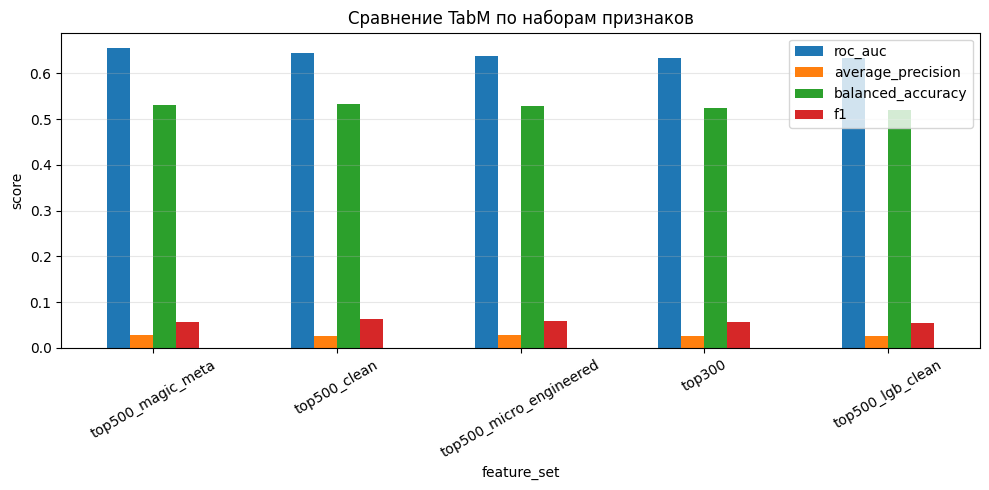

In [19]:
metrics_to_plot = ["roc_auc", "average_precision", "balanced_accuracy", "f1"]

final_results_df.set_index("feature_set")[metrics_to_plot].plot(
    kind="bar", figsize=(10, 5), rot=30, title=f"Сравнение {MODEL_NAME} по наборам признаков"
)

plt.ylabel("score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
best_folder = final_results_df.loc[0, "feature_set"]
best_model_path = Path(final_results_df.loc[0, "model_path"])

print("best feature set:", best_folder)
print("best model:", best_model_path)
print("best val roc auc:", final_results_df.loc[0, "roc_auc"])
print("best threshold:", final_results_df.loc[0, "threshold"])

best feature set: top500_magic_meta
best model: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/models/tabm_models/tabm_top500_magic_meta_0.65617.pt
best val roc auc: 0.6561725230140733
best threshold: 0.86799484


## Confusion matrix для лучшей модели

read val           top500_magic_meta         -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_magic_meta/X_val_top500_magic_meta.parquet


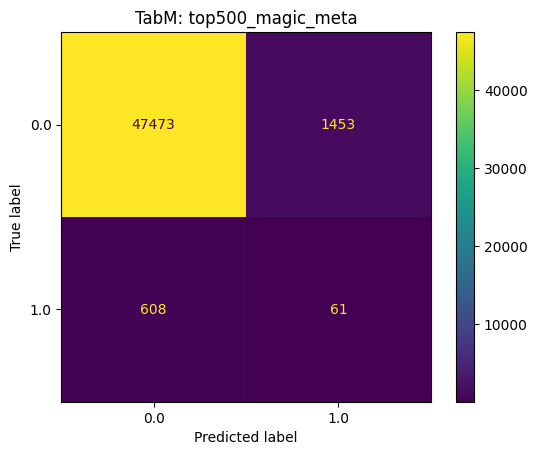

roc auc: 0.6561725230140733
average precision: 0.027509296202705487
balanced accuracy: 0.5307414779172621
f1: 0.055886394869445716


In [21]:
checkpoint = load_checkpoint(best_model_path)
best_params = checkpoint["params"]
scaler = checkpoint["scaler"]

X_val_best = read_feature_matrix(best_folder, "val")
X_val_best_np = X_val_best.to_numpy(dtype=np.float32, copy=True)
X_val_best_np = np.nan_to_num(X_val_best_np, nan=0.0, posinf=0.0, neginf=0.0)
X_val_best_np = scaler.transform(X_val_best_np).astype(np.float32)

val_loader_best = make_loader(X_val_best_np, y_val, best_params["batch_size"], shuffle=False, params=best_params)

best_model = make_model(X_val_best_np.shape[1], best_params).to(DEVICE)
best_model.load_state_dict(checkpoint["state_dict"])

y_score_best = predict_scores(best_model, val_loader_best)
y_pred_best = predict_with_threshold(
    y_score_best, final_thresholds.get(best_folder, final_results_df.loc[0, "threshold"])
)

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_best)
plt.title(f"{MODEL_NAME}: {best_folder}")
plt.show()

count_metrics(y_val, y_pred_best, y_score_best)

del X_val_best, X_val_best_np, val_loader_best, best_model, y_score_best, y_pred_best
gc.collect()
if DEVICE.type == "mps":
    torch.mps.empty_cache()
elif DEVICE.type == "cuda":
    torch.cuda.empty_cache()

## Предсказание для test и сабмит

In [22]:
RUN_SUBMISSION = True

if RUN_SUBMISSION:
    checkpoint = load_checkpoint(best_model_path)
    best_params = checkpoint["params"]
    scaler = checkpoint["scaler"]

    X_test = read_feature_matrix(best_folder, "test")
    X_test_np = X_test.to_numpy(dtype=np.float32, copy=True)
    X_test_np = np.nan_to_num(X_test_np, nan=0.0, posinf=0.0, neginf=0.0)
    X_test_np = scaler.transform(X_test_np).astype(np.float32)

    test_loader = make_loader_for_prediction(X_test_np, best_params["batch_size"], best_params)

    best_model = make_model(X_test_np.shape[1], best_params).to(DEVICE)
    best_model.load_state_dict(checkpoint["state_dict"])
    test_score = predict_scores(best_model, test_loader)

    submit_candidates = [
        DATA_DIR / "sample_submission.csv",
        DATA_DIR / "submit.csv",
        PROJECT_DIR / "sample_submission.csv",
        PROJECT_DIR / "submit.csv",
    ]
    submit_path = next((path for path in submit_candidates if path.exists()), None)

    if submit_path is not None:
        submission = pd.read_csv(submit_path)
        target_col = "target" if "target" in submission.columns else submission.columns[-1]
        submission[target_col] = test_score
    else:
        submission = pd.DataFrame(
            {
                "index": X_test.index,
                "target": test_score,
            }
        )

    submission_path = SUBMISSIONS_DIR / f"{MODEL_PREFIX}_{best_folder}_{final_results_df.loc[0, 'roc_auc']:.5f}.csv"
    submission.to_csv(submission_path, index=False)

    print("submission saved:", submission_path)
    display(submission.head())

    del X_test, X_test_np, test_loader, best_model, test_score
    gc.collect()
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    elif DEVICE.type == "cuda":
        torch.cuda.empty_cache()

read test          top500_magic_meta         -> /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/data/top500_magic_meta/X_test_top500_magic_meta.parquet
submission saved: /Users/pinta/hse/mlproject/ml-project-adaai_VK_predict_hackaton/submissions/tabm_top500_magic_meta_0.65617.csv


,index,score
0,194357,0.021211
1,313222,0.116028
2,321873,0.568204
3,118689,0.675872
4,342561,0.074849
